In [ ]:
import numpy
import torch
import os

from rcnn_detection_utils import intersection_over_union, non_max_suppression, bbox_delta, bbox_delta_to_box
from rcnn_dataset import RCNNDataset
from rcnn_model import RCNN

from torch.utils.data import DataLoader
from torchvision import transforms

!pip -q install selectivesearch
import selectivesearch
import cv2

  Preparing metadata (setup.py) ... done


In [2]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

Using Colab cache for faster access to the 'pascal-voc-2007' dataset.


In [3]:
import os
import xml.etree.ElementTree as ET

annotations_dir = None
images_dir = None

#The dataset is very messy or we are auto finding the folder's or dir's path we needs
for root_dir, dirs, files in os.walk(path):
    if "Annotations" in dirs:
        annotations_dir = os.path.join(root_dir, "Annotations")
    if "JPEGImages" in dirs:
        images_dir = os.path.join(root_dir, "JPEGImages")

if not annotations_dir or not images_dir:
    raise FileNotFoundError("Could not find Annotations or JPEGImages folders in the dataset.")

print(f"Found Annotations at: {annotations_dir}")
print(f"Found Images at: {images_dir}")
print("-" * 50)

#Extracting only the three classes for this small experiment
target_classes = {"person", "dog", "car"}
filtered_dataset = []

for xml_filename in os.listdir(annotations_dir):
    if not xml_filename.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    target_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name in target_classes:
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            target_objects.append({
                "class_name": class_name,
                "bbox": [xmin, ymin, xmax, ymax]
            })

    if len(target_objects) > 0:
        filtered_dataset.append({
            "image_path": image_path,
            "objects": target_objects
        })

print(f"Successfully processed {len(filtered_dataset)} images containing a person, dog, or car.")
print(f"Sample data: {filtered_dataset[0]}")

Found Annotations at: /kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/Annotations
Found Images at: /kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages
--------------------------------------------------
Successfully processed 2878 images containing a person, dog, or car.
Sample data: {'image_path': '/kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/006625.jpg', 'objects': [{'class_name': 'car', 'bbox': [284, 151, 319, 177]}, {'class_name': 'car', 'bbox': [120, 141, 179, 213]}, {'class_name': 'car', 'bbox': [17, 146, 111, 243]}, {'class_name': 'person', 'bbox': [102, 153, 152, 266]}, {'class_name': 'person', 'bbox': [69, 157, 100, 261]}, {'class_name': 'person', 'bbox': [19, 156, 58, 283]}]}


In [4]:
#While this code did work it just that we don't be able to show it the way i wanted it to be that is 4*4 grid of 16 image

#Randomly picking 16 images with ground truth box for visuallization
# import random
# from google.colab.patches import cv2_imshow

# Loop for puting the box and class name on the img
# for i in range(16):
#   random_idx=random.randint(0,len(filtered_dataset))
#   img=cv2.imread(filtered_dataset[random_idx]["image_path"])
#   for obj in filtered_dataset[random_idx]["objects"]:
#     class_name = obj["class_name"]
#     bbox = obj["bbox"]
#     cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
#     cv2.putText(img, class_name, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

#   cv2_imshow(img)
#   cv2.waitKey(0)
#   cv2.destroyAllWindows()

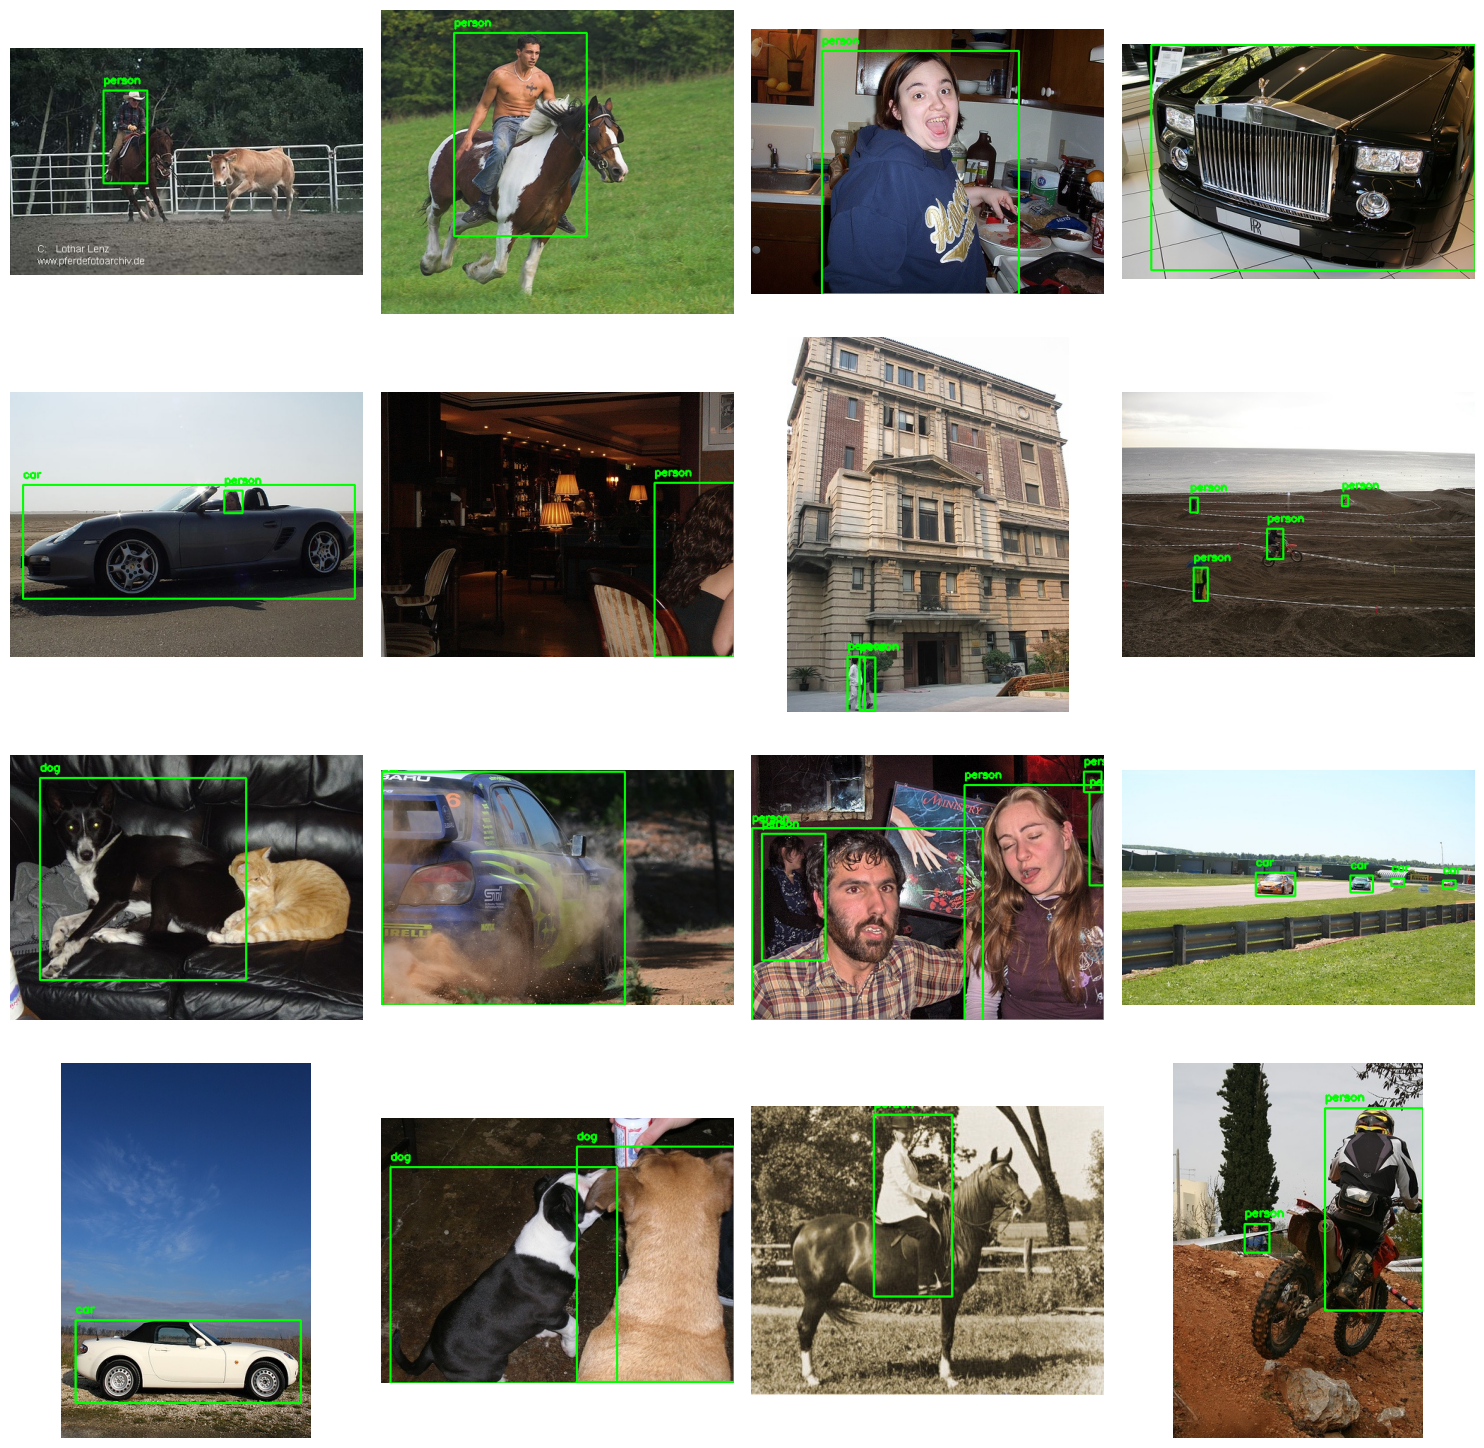

In [5]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

sample_indices = random.sample(range(len(filtered_dataset)), 16) # Using the random.sample rather than randint for 16 unique indices

# Create a 4x4 grid for plot
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

#Adding all the ground truth boxes for each img for visualization
for idx, ax in zip(sample_indices, axes):
    img = cv2.imread(filtered_dataset[idx]["image_path"])

    for obj in filtered_dataset[idx]["objects"]:
        class_name = obj["class_name"]
        bbox = obj["bbox"]

        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, class_name, (bbox[0], max(0, bbox[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()

sns.despine()
plt.show()

In [6]:
def extract_proposals(images,max_proposals=2000):
  '''
     images: cv2 images(H,W,C)
     max_proposals: int (max proposals per image default=2000)
  '''
  _,regions=selectivesearch.selective_search(images,scale=500,sigma=0.9,min_size=10)

  proposals=[]
  for r in regions:
    if r['rect'] == (0,0,images.shape[1],images.shape[0]):
      continue

    x,y,w,h=r['rect']
    if w>0 and h>0:
      proposals.append([x,y,x+w,y+h])

  proposals=list(set(tuple(x) for x in proposals))
  proposals=proposals[:max_proposals]

  return proposals[:max_proposals]

#### Saving a json file
This rcnn_proposals_data will contain the image path , seleative search proposals and ground truth.
* image_path
* croped_boxs
* ground_truth

In [ ]:
#proposal boxes and ground truth with img_path to a json file
import json

all_data=[]
output_file="rcnn_proposals_data.json"

for i in range(0,len(filtered_dataset)):
  img_path=filtered_dataset[i]["image_path"]
  img=cv2.imread(img_path)
  if img is None:
    continue

  croped_boxs= extract_proposals(img, max_proposals=500)

  all_data.append({
                  "image_path":img_path,
                  "croped_boxs":croped_boxs,
                  "ground_truth":filtered_dataset[i]["objects"]
                  })
  if (i + 1) % 100 == 0 or (i + 1) == len(filtered_dataset):
        print(f"Processed {i + 1}/{len(filtered_dataset)} images")
with open(output_file, 'w') as f:
    json.dump(all_data, f)

print(f"Successfully saved proposal data to {output_file}")

/usr/local/lib/python3.13/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Processed 25/2895 images
Processed 50/2895 images
Processed 75/2895 images


KeyboardInterrupt: 

In [7]:
#Checking the math of bbox_delta and bbox_delta_to_box
a=torch.tensor([23,43,28,49])
b=torch.tensor([26,30,33,40])
delta=bbox_delta(a,b)
print(f"delta: {delta}")
box,refined_box=bbox_delta_to_box(delta,b)
print(f"box: {box}")
print(f"refined_box: {refined_box}")

delta: tensor([-0.5714,  1.1000, -0.3365, -0.5108])
box: tensor([25.5000, 46.0000,  5.0000,  6.0000])
refined_box: tensor([23., 43., 28., 49.])


#### Creating test and train data and dataset

In [9]:
import json

with open("rcnn_proposals_data.json", 'r') as f:
            all_data = json.load(f)

print(f"So the Lenght of all_data is {len(all_data)}")
print(f"so train data(80% of all_data) will have a len of {int(len(all_data)*0.8)}")
print(f"so test data(20% of all_data) will have a len of {int(len(all_data)*0.2)}")

train_data=all_data[:int(len(all_data)*0.8)]
test_data=all_data[int(len(all_data)*0.8):]

with open("train_data.json", 'w') as f:
            json.dump(train_data, f)

with open("test_data.json", 'w') as f:
            json.dump(test_data, f)

So the Lenght of all_data is 2878
so train data(80% of all_data) will have a len of 2302
so test data(20% of all_data) will have a len of 575


In [10]:
import json

with open("train_data.json", 'r') as f:
            train_data = json.load(f)

with open("test_data.json", 'r') as f:
            test_data = json.load(f)

print(f"So the Lenght of train_data is {len(train_data)}")
print(f"So the Lenght of test_data is {len(test_data)}")

So the Lenght of train_data is 2302
So the Lenght of test_data is 576


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE=32

transform=transforms.Compose([
                              transforms.ToTensor(),
                              transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                             ])

train_dataset=RCNNDataset(json_path="train_data.json",
                          transform=transform)

test_dataset=RCNNDataset(json_path="test_data.json",
                         transform=transform)

train_dataloader=DataLoader(
                            dataset=train_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=0,
                            pin_memory=True,
                            shuffle=True
                            )
test_dataloader=DataLoader(
                            dataset=test_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=0,
                            pin_memory=True,
                            shuffle=False
                            )

Dataset ready! Total training samples: 78559
Dataset ready! Total training samples: 19796


### Visualize

In [12]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a4ad07e42f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a4aeddd7c50>)

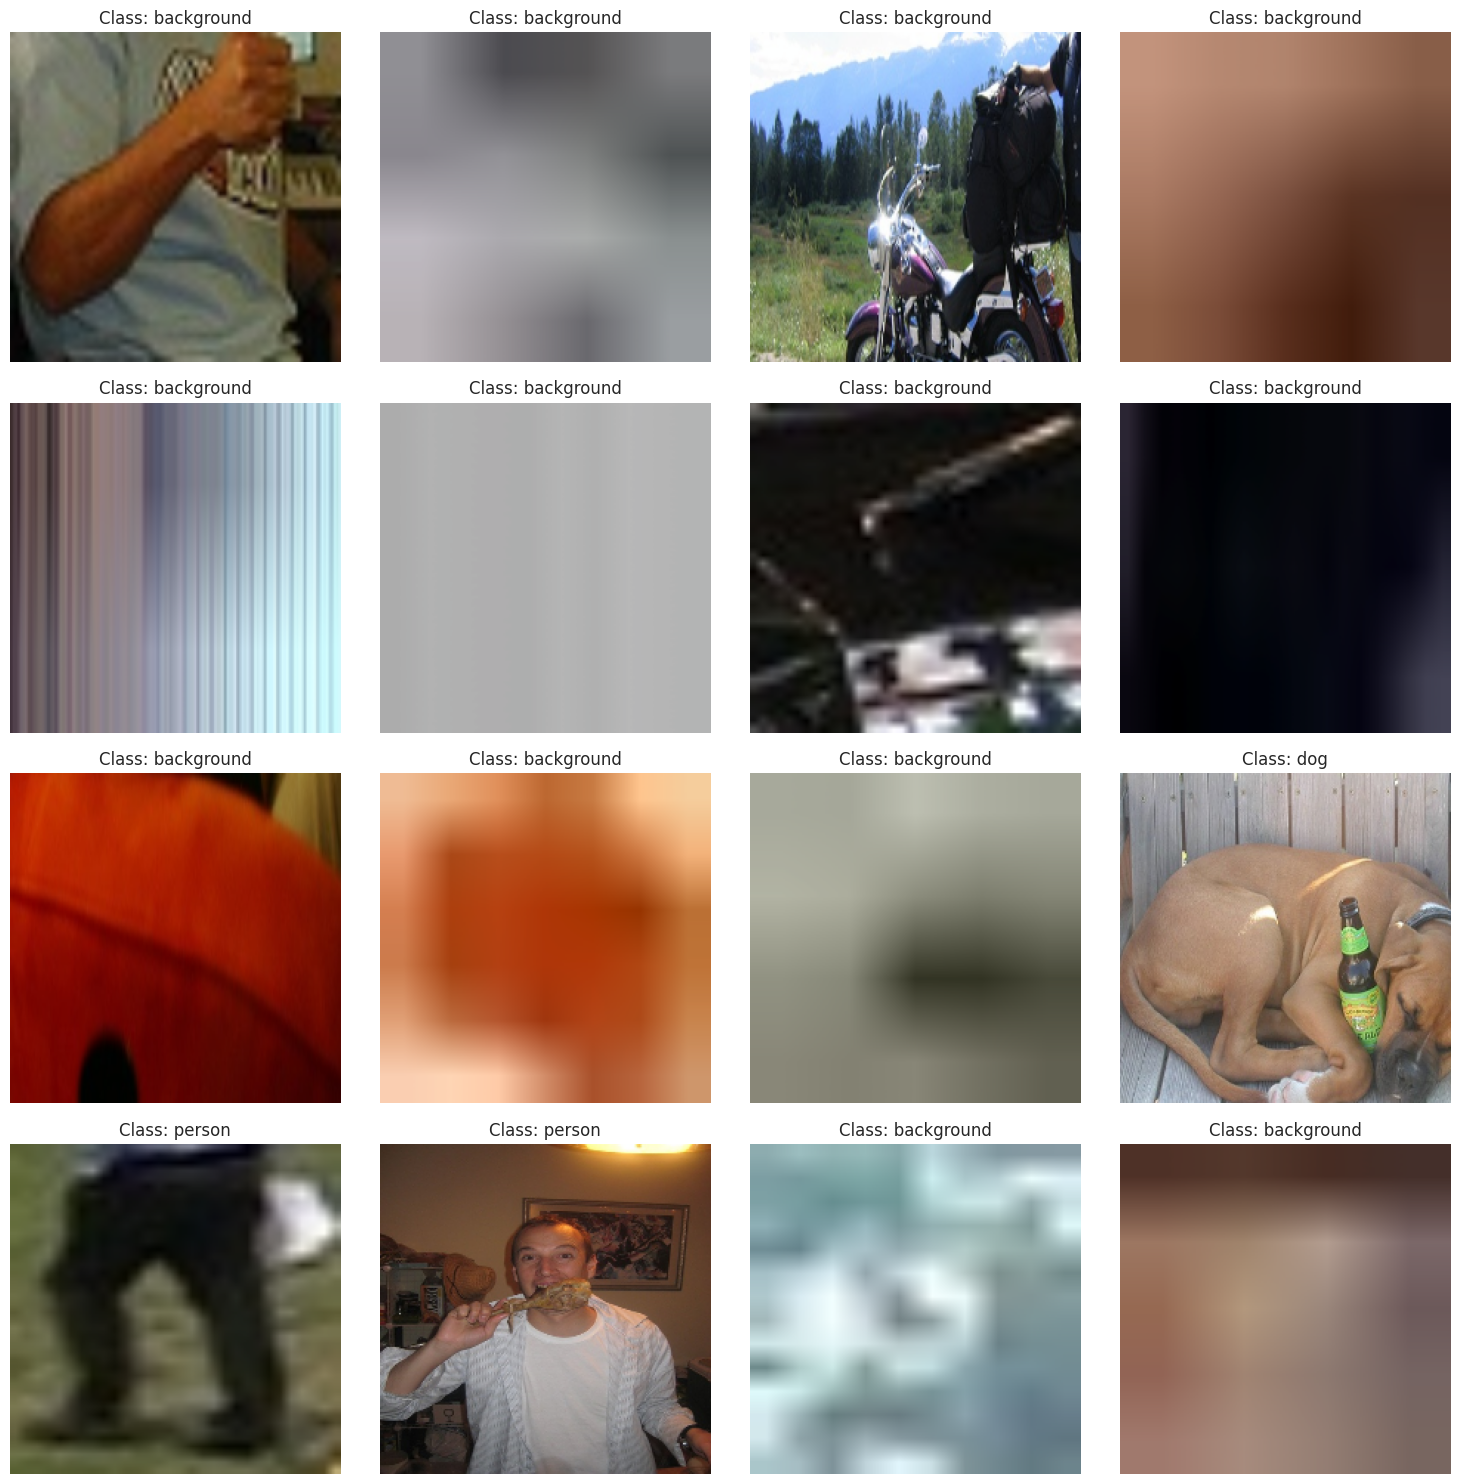

In [13]:
import numpy as np
import random
import PIL

sns.set_theme(style="darkgrid")

crop_tensor_batch,labels,delta=next(iter(train_dataloader))

sample_indices=random.sample(range(len(crop_tensor_batch)),16)

_,axes=plt.subplots(4,4,figsize=(15,15))
axes=axes.flatten()

for idx,ax in zip(sample_indices,axes):
  img=crop_tensor_batch[idx].permute(1,2,0).numpy()
  #Converting normalized to normal
  img=img*np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
  img=img.clip(0,1)

  label=labels[idx]
  if label==0:
    label="background"
  elif label==1:
    label="person"
  elif label==2:
    label="dog"
  elif label==3:
    label="car"

  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Class: {label}")

plt.tight_layout()

sns.despine()
plt.show()

In [14]:
model=RCNN()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]


In [15]:
!pip -q install torchmetrics
import torchmetrics
import torch.nn as nn

class_loss=nn.CrossEntropyLoss()
bbox_loss=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.7 MB/s eta 0:00:00


In [16]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from tqdm.auto import tqdm
from timeit import default_timer as timer


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

acc_metric=MulticlassAccuracy(num_classes=4).to(device)
f1_metric=MulticlassF1Score(num_classes=4).to(device)

start_time=timer()
epochs=10

history= {
    'total_loss': [],
    'cls_loss': [],
    'bbox_loss':[],
    'accuracy': [],
    'f1_score': [],
}

for epoch in tqdm(range(epochs)):
  model.train()
  running_total_loss = 0.0
  running_cls_loss = 0.0
  running_bbox_loss = 0.0

  acc_metric.reset()
  f1_metric.reset()

  for crop_tensor_batch,labels,delta in train_dataloader:
    crop_tensor_batch=crop_tensor_batch.to(device)
    labels=labels.to(device)
    delta=delta.to(device)

    class_logits,bbox_delta=model(crop_tensor_batch)

    class_loss_value=class_loss(class_logits,labels)
    preds = torch.argmax(class_logits, dim=1)
    acc_metric.update(preds, labels)
    f1_metric.update(preds, labels)

    fg_mask = labels>0
    if fg_mask.sum() > 0:
      bbox_loss_value=bbox_loss(bbox_delta[fg_mask],delta[fg_mask])
    else:
      bbox_loss_value=torch.tensor(0.0, device=device)

    total_loss=class_loss_value+(5*bbox_loss_value)

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()

    running_total_loss += total_loss.item()
    running_cls_loss += class_loss_value.item()
    running_bbox_loss += bbox_loss_value.item()

  n_batches = len(train_dataloader)
  epoch_total_loss = running_total_loss / n_batches
  epoch_cls_loss = running_cls_loss / n_batches
  epoch_bbox_loss = running_bbox_loss / n_batches
  epoch_accuracy = acc_metric.compute().item()
  epoch_f1_score = f1_metric.compute().item()

  history['total_loss'].append(epoch_total_loss)
  history['cls_loss'].append(epoch_cls_loss)
  history['bbox_loss'].append(epoch_bbox_loss)
  history['accuracy'].append(epoch_accuracy)
  history['f1_score'].append(epoch_f1_score)

  print(f"\nEpoch [{epoch+1}/{epochs}] | Loss: {epoch_total_loss:.4f} (Cls: {epoch_cls_loss:.4f}, Reg: {epoch_bbox_loss:.4f}) | Acc: {epoch_accuracy*100:.2f}% | F1: {epoch_f1_score:.4f}")

end_time=timer()
total_time=end_time-start_time
print(f"Total Training Time: {total_time/60:.3f} minutes")

  0%|          | 0/10 [00:00<?, ?it/s]


Epoch [1/10] | Loss: 0.3788 (Cls: 0.2044, Reg: 0.0349) | Acc: 63.89% | F1: 0.6978

Epoch [2/10] | Loss: 0.2899 (Cls: 0.1334, Reg: 0.0313) | Acc: 80.22% | F1: 0.8204

Epoch [3/10] | Loss: 0.2695 (Cls: 0.1233, Reg: 0.0292) | Acc: 82.79% | F1: 0.8405

Epoch [4/10] | Loss: 0.2593 (Cls: 0.1157, Reg: 0.0287) | Acc: 83.62% | F1: 0.8508

Epoch [5/10] | Loss: 0.2486 (Cls: 0.1111, Reg: 0.0275) | Acc: 83.81% | F1: 0.8523

Epoch [6/10] | Loss: 0.2444 (Cls: 0.1077, Reg: 0.0273) | Acc: 84.78% | F1: 0.8600

Epoch [7/10] | Loss: 0.2355 (Cls: 0.1026, Reg: 0.0266) | Acc: 85.65% | F1: 0.8704

Epoch [8/10] | Loss: 0.2300 (Cls: 0.1006, Reg: 0.0259) | Acc: 85.83% | F1: 0.8723

Epoch [9/10] | Loss: 0.2258 (Cls: 0.0979, Reg: 0.0256) | Acc: 86.03% | F1: 0.8730

Epoch [10/10] | Loss: 0.2222 (Cls: 0.0955, Reg: 0.0253) | Acc: 86.60% | F1: 0.8789
Total Training Time: 70.410 minutes


In [17]:
torch.save(model.state_dict(), "rcnn_model.pth")

### Graphs

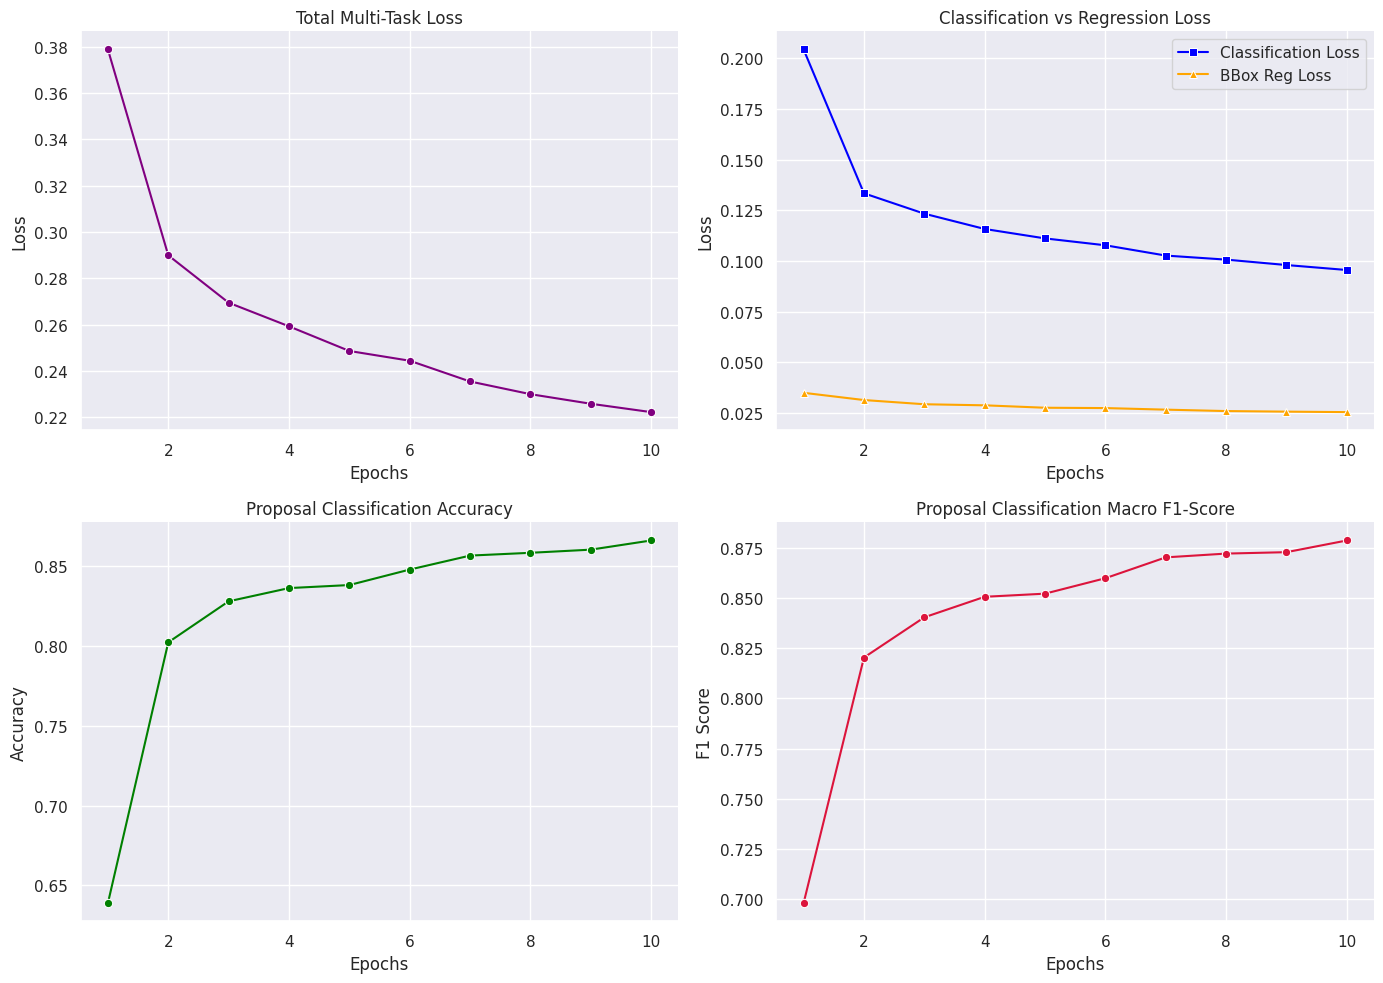

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
epochs_range = list(range(1, epochs + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total Multi-task Loss
sns.lineplot(ax=axes[0, 0], x=epochs_range, y=history['total_loss'], marker='o', color='purple')
axes[0, 0].set_title("Total Multi-Task Loss")
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("Loss")

# 2. Classification vs. Regression Loss
sns.lineplot(ax=axes[0, 1], x=epochs_range, y=history['cls_loss'], label='Classification Loss', marker='s', color='blue')
sns.lineplot(ax=axes[0, 1], x=epochs_range, y=history['bbox_loss'], label='BBox Reg Loss', marker='^', color='orange')
axes[0, 1].set_title("Classification vs Regression Loss")
axes[0, 1].set_xlabel("Epochs")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# 3. Macro Accuracy
sns.lineplot(ax=axes[1, 0], x=epochs_range, y=history['accuracy'], marker='o', color='green')
axes[1, 0].set_title("Proposal Classification Accuracy")
axes[1, 0].set_xlabel("Epochs")
axes[1, 0].set_ylabel("Accuracy")

# 4. Macro F1-Score
sns.lineplot(ax=axes[1, 1], x=epochs_range, y=history['f1_score'], marker='o', color='crimson')
axes[1, 1].set_title("Proposal Classification Macro F1-Score")
axes[1, 1].set_xlabel("Epochs")
axes[1, 1].set_ylabel("F1 Score")

plt.tight_layout()
sns.despine()
plt.show()

### Evaluating

In [22]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from PIL import Image
from torchvision.ops import nms

metric = MeanAveragePrecision(iou_type="bbox")
model.eval()

class_map = {"background": 0, "person": 1, "dog": 2, "car": 3}

eval_samples = test_data

for item in eval_samples:
    img_path = item["image_path"]
    proposals = item["croped_boxs"]
    ground_truth = item["ground_truth"]

    if len(proposals) == 0 or len(ground_truth) == 0:
        continue

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 1. Prepareing target boxes & labels
    gt_boxes = torch.tensor([obj["bbox"] for obj in ground_truth], dtype=torch.float32)
    gt_labels = torch.tensor([class_map[obj["class_name"]] for obj in ground_truth], dtype=torch.int64)

    targets = [{"boxes": gt_boxes, "labels": gt_labels}]

    # 2. Extract crops and prepare tensor batch
    crop_tensors = []
    valid_props = []
    for prop in proposals:
        x1, y1, x2, y2 = prop
        crop = img_rgb[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
            continue
        crop_pil = Image.fromarray(crop).resize((224, 224))
        crop_tensors.append(transform(crop_pil))
        valid_props.append(prop)

    if len(crop_tensors) == 0:
        continue

    batch_tensors = torch.stack(crop_tensors).to(device)
    valid_props_tensor = torch.tensor(valid_props, dtype=torch.float32).to(device)

    with torch.no_grad():
        class_logits, bbox_deltas = model(batch_tensors)
        probs = torch.softmax(class_logits, dim=1)
        scores, pred_classes = torch.max(probs, dim=1)

    # 3. Filter out background proposals (keep class > 0 with score > 0.5)
    fg_indices = (pred_classes > 0) & (scores > 0.15)

    if fg_indices.sum() == 0:
        preds = [{
            "boxes": torch.empty((0, 4), dtype=torch.float32),
            "scores": torch.empty((0,), dtype=torch.float32),
            "labels": torch.empty((0,), dtype=torch.int64)
        }]
    else:
        fg_scores = scores[fg_indices].cpu()
        fg_classes = pred_classes[fg_indices].cpu()
        fg_deltas = bbox_deltas[fg_indices]
        fg_props = valid_props_tensor[fg_indices]

        # Refine boxes with predicted deltas
        # Refine boxes with predicted deltas one by one
        refined_boxes = []

        for d, p in zip(fg_deltas, fg_props):
            _, r_box = bbox_delta_to_box(d, p)
            refined_boxes.append(r_box)

        refined_boxes = torch.stack(refined_boxes).cpu()

        # Applying NMS per class
        keep_boxes, keep_scores, keep_labels = [], [], []
        for c in range(1, 4):
            c_mask = fg_classes == c
            if c_mask.sum() == 0:
                continue
            nms_idx = nms(refined_boxes[c_mask], fg_scores[c_mask], iou_threshold=0.3)

            keep_boxes.append(refined_boxes[c_mask][nms_idx])
            keep_scores.append(fg_scores[c_mask][nms_idx])
            keep_labels.append(fg_classes[c_mask][nms_idx])

        if len(keep_boxes) > 0:
            preds = [{
                "boxes": torch.cat(keep_boxes),
                "scores": torch.cat(keep_scores),
                "labels": torch.cat(keep_labels)
            }]
        else:
            preds = [{
                "boxes": torch.empty((0, 4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty((0,), dtype=torch.int64)
            }]

    metric.update(preds, targets)

# Compute final mAP metrics
results = metric.compute()
print(f"Mean Average Precision (mAP@50):    {results['map_50'].item():.4f}")
print(f"Mean Average Precision (mAP@50:95): {results['map'].item():.4f}")

Mean Average Precision (mAP@50):    0.2472
Mean Average Precision (mAP@50:95): 0.0877
